# Install the packages

!pip install pandas
!pip install matplotlib.pyplot
!pip install seaborn
!pip install wordcloud

# Import the packages

In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import re
from wordcloud import STOPWORDS
from wordcloud import WordCloud
import datetime as dt
import numpy as np

# Data loading and Cleaning




In [2]:
import pandas as pd

df_original= pd.read_csv(r"C:\Users\adeel\.cache\kagglehub\datasets\carrie1\ecommerce-data\versions\1\data.csv",encoding='latin1')

In [3]:

df = df_original


In [4]:
def df_summary(df):
    """SUMMARY."""
    print("=== SHAPE ===")
    print(df.shape)
    
    print("\n=== DTYPES ===")
    print(df.dtypes)
    
    print("\n=== INFO ===")
    df.info()
    
    print("\n=== DESCRIBE ===")
    print(df.describe())
    
    print("\n=== MISSING VALUES (count per column) ===")
    print(df.isnull().sum())
    
    print("\n=== HEAD (first 5 rows) ===")
    print(df.head())

In [5]:
df_summary(df)

=== SHAPE ===
(541909, 8)

=== DTYPES ===
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB

=== DESCRIBE ===
            Quantity      UnitPrice     CustomerID
count  541909.000000  541909.000000  406829.000000
mean        9.552250   

# Summary

1. The Start shape is (541909, 8)
2. Dtypes:
    InvoiceNo    : the Invoice number is read as a object.this must be investigated.
    InvoiceDate  : The Invoice date is seen as a object ,In order for the analysis it must be converted into datetime.
    CustomerID   : This has a Dtype of float lets go ahead and change it into int
3. MISSING VALUES
    CustomerID   : The null count of the customer id's show 135080 missing values. This will comes back to haunt me later so lets get rid of these.
    Description  : The missing values in the description will probably be removed once the empty rows ain the customer id are droped


# Data Cleaning

In [6]:
#lets start with removing the missing rows:

df.dropna(subset=('CustomerID'), inplace=True)

In [7]:
# Invoice Number

print(df[df['InvoiceNo'].str.contains('[A-Za-z]', na=False)]['InvoiceNo'].unique())

#we can see that  some of the invoice numbers contain the letter 'C' in there beginning refereing to concelled invoices.We can go ahead and Remove
#But firt lets Check the Quantities of the the products corresponding to these invoices

['C536379' 'C536383' 'C536391' ... 'C581499' 'C581568' 'C581569']


In [8]:
cancelled_invoices = df[df['InvoiceNo'].str.contains('[A-Za-z]', na=False)]['InvoiceNo'].unique()

cancelled_rows = df[df['InvoiceNo'].isin(cancelled_invoices)]
print(cancelled_rows[['InvoiceNo', 'Quantity']])


       InvoiceNo  Quantity
141      C536379        -1
154      C536383        -1
235      C536391       -12
236      C536391       -24
237      C536391       -24
...          ...       ...
540449   C581490       -11
541541   C581499        -1
541715   C581568        -5
541716   C581569        -1
541717   C581569        -5

[8905 rows x 2 columns]


In [9]:
#if All the quantites are negative we can go ahead and remove all these rows as they will mess with the results.
cancelled_rows = df[df['InvoiceNo'].isin(cancelled_invoices)]

if (cancelled_rows['Quantity'] < 0).all():
    print('All are negative')
else:
    print('some are not')

All are negative


In [10]:

df.drop(df[df['InvoiceNo'].isin(cancelled_invoices)].index, inplace=True)

In [11]:
print(df[df['InvoiceNo'].str.contains('[A-Za-z]', na=False)]['InvoiceNo'].unique())

[]


#change the date column to a dtype of datatime and the custumer id as int64

In [12]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [13]:
df['CustomerID'] = df['CustomerID'].astype('int64')

In [14]:
# check if any duplicate rows are there

# Check if there is at least one duplicate row (anywhere in the DataFrame)
has_duplicates = df.duplicated().any()
print("Are there duplicate rows?", has_duplicates)

# If True, you can also see how many:
n_duplicates = df.duplicated().sum()
print("Number of duplicate rows:", n_duplicates)



Are there duplicate rows? True
Number of duplicate rows: 5192


In [15]:
df.drop_duplicates(inplace=True)

In [16]:
df_summary(df)

# So the shape changed from (541909, 8) -to-> (397924, 8) -to-> (392732, 8)  ,Also from the info column we can see that data is balances and no missing rows are there.

=== SHAPE ===
(392732, 8)

=== DTYPES ===
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              int64
Country                object
dtype: object

=== INFO ===
<class 'pandas.core.frame.DataFrame'>
Index: 392732 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392732 non-null  object        
 1   StockCode    392732 non-null  object        
 2   Description  392732 non-null  object        
 3   Quantity     392732 non-null  int64         
 4   InvoiceDate  392732 non-null  datetime64[ns]
 5   UnitPrice    392732 non-null  float64       
 6   CustomerID   392732 non-null  int64         
 7   Country      392732 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 27.0+ MB

==

# Problem Statement

The marketing team of the Uk-Based retail chain to who have made this data available wants a couple a insights from this data.
 **Team Objectives**

 1. Where are our customers based and what percentage belongs to which region
 2. What days do most of our custumer choose to shop.
 3. how much revenue is being generated from each region.
 4. how many customers belong to each region.
 5. what are the overall top StockCodes.
 6. What are the top stock in each region.


## 1.Where are our customers based and what percentage belongs to which region

In [17]:
#1. Where are our customers based and what percentage belongs to which region

country_counts= df['Country'].value_counts()
country_pct = df["Country"].value_counts(normalize=True)*100


region_table= pd.DataFrame( {'country' :country_counts.index,
                            "Country Count": country_counts,
                            "Percentage" : country_pct}).round(2)

region_table.head(10)

,country,Country Count,Percentage
Country,,,
United Kingdom,United Kingdom,349227,88.92
Germany,Germany,9027,2.30
France,France,8327,2.12
EIRE,EIRE,7228,1.84
Spain,Spain,2480,0.63
Netherlands,Netherlands,2363,0.60
Belgium,Belgium,2031,0.52
Switzerland,Switzerland,1842,0.47
Portugal,Portugal,1453,0.37


In [18]:

customers_per_country = df.groupby('Country')['CustomerID'].nunique()  # one row per country, count of distinct customers

pct_per_country = (
    df.groupby('Country')['CustomerID']
    .nunique()
    .pipe(lambda x: x / x.sum() * 100)  # percentage of total customers
).round(2)

region_table = pd.DataFrame({
    'Country': customers_per_country.index,
    'Customer Count': customers_per_country.values,
    'Percentage (%)': pct_per_country.values
}).sort_values('Customer Count', ascending=False) 

region_table.head(40)

,Country,Customer Count,Percentage (%)
35,United Kingdom,3921,90.20
14,Germany,94,2.16
13,France,87,2.00
30,Spain,30,0.69
3,Belgium,25,0.58
32,Switzerland,21,0.48
26,Portugal,19,0.44
18,Italy,14,0.32
12,Finland,12,0.28
1,Austria,11,0.25


In [19]:
top4 = customers_per_country.sort_values(ascending=False).head(4)

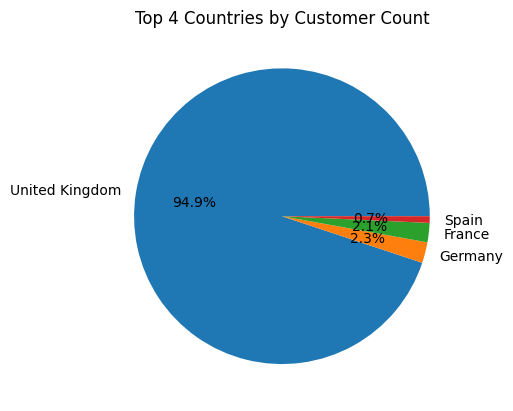

In [20]:
top4.plot.pie(
    autopct='%.1f%%',
    labels=top4.index,
    ylabel='',   # removes default 'ylabel'
    title='Top 4 Countries by Customer Count'
)
plt.show()

# At this point its clear that UK dominates the sales ,Moving forward any analysis run will be biased towards uk.So for argument sake lets break this process down to gain insights into 2 disticts segments

**1. Global - Here we will put it all together, to gain further insights**


**2. Regional segment - Here only bussiness coming from outside the region will be visulised**


Now lets see the days by making a day column in our data frame

# Global

## 2. What days do most of our custumer choose to shop.

In [21]:
# Add a column with the day of the week as numbers
df['day_number'] = df['InvoiceDate'].dt.dayofweek

# Map the day number to its name
day_mapping = {
    0: 'Monday',
    1: 'Tuesday', 
    2: 'Wednesday',
    3: 'Thursday',
    4: 'Friday',
    5: 'Saturday',
    6: 'Sunday'
}

df['day_name'] = df['day_number'].map(day_mapping)
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,day_number,day_name
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,2,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,2,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2,Wednesday


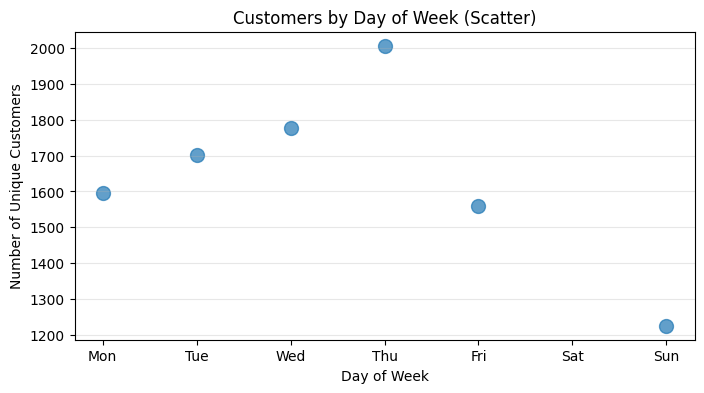

In [22]:
day_counts = df.groupby('day_name')['CustomerID'].nunique().reset_index(name='unique_customers')

weekday_order = {
    'Monday': 0,
    'Tuesday': 1,
    'Wednesday': 2,
    'Thursday': 3,
    'Friday': 4,
    'Saturday': 5,
    'Sunday': 6
}

day_counts['day_num'] = day_counts['day_name'].map(weekday_order)

plt.figure(figsize=(8, 4))
plt.scatter(day_counts['day_num'], day_counts['unique_customers'], s=100, alpha=0.7)

plt.xticks(
    ticks=[0, 1, 2, 3, 4, 5, 6],
    labels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
)
plt.xlabel('Day of Week')
plt.ylabel('Number of Unique Customers')
plt.title('Customers by Day of Week (Scatter)')
plt.grid(True, axis='y', alpha=0.3)
plt.show()

#  3. how much revenue is being generated from each region.

In [23]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,day_number,day_name
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,2,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,2,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2,Wednesday


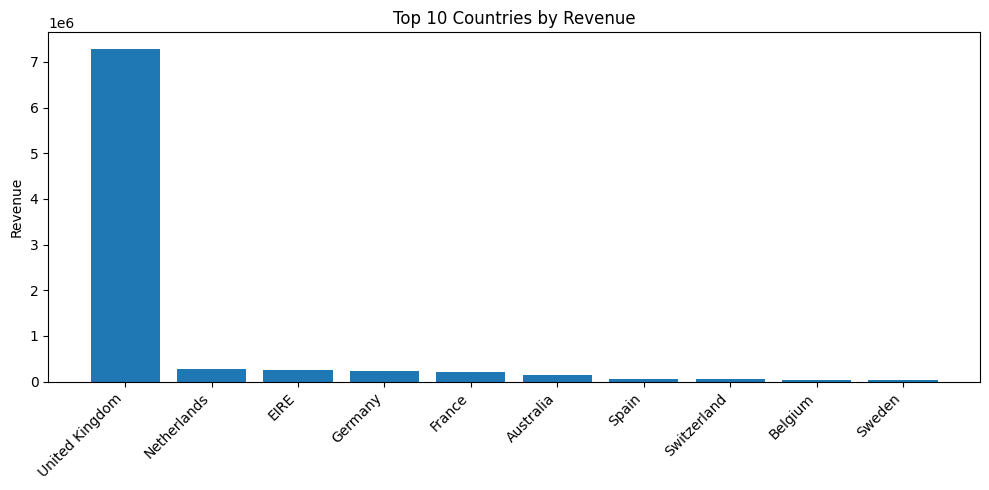

In [24]:
df['Total_sales']= df['Quantity'] * df['UnitPrice']
revenue_by_country = df.groupby('Country')['Total_sales'].sum().sort_values(ascending=False).reset_index()

revenue_by_country['Percentage (%)'] = (
    revenue_by_country['Total_sales'] / revenue_by_country['Total_sales'].sum() * 100
).round(2)

revenue_by_country



top10 = revenue_by_country.head(10)

plt.figure(figsize=(10, 5))
plt.bar(top10['Country'], top10['Total_sales'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Revenue')
plt.title('Top 10 Countries by Revenue')
plt.tight_layout()
plt.show()

## 4. how many customers belong to each region.

In [25]:
Number_of_customer = df.groupby('Country')['CustomerID'].nunique().sort_values(ascending=False)

In [26]:
Number_of_customer.head(16)

Country
United Kingdom     3921
Germany              94
France               87
Spain                30
Belgium              25
Switzerland          21
Portugal             19
Italy                14
Finland              12
Austria              11
Norway               10
Australia             9
Denmark               9
Netherlands           9
Channel Islands       9
Japan                 8
Name: CustomerID, dtype: int64

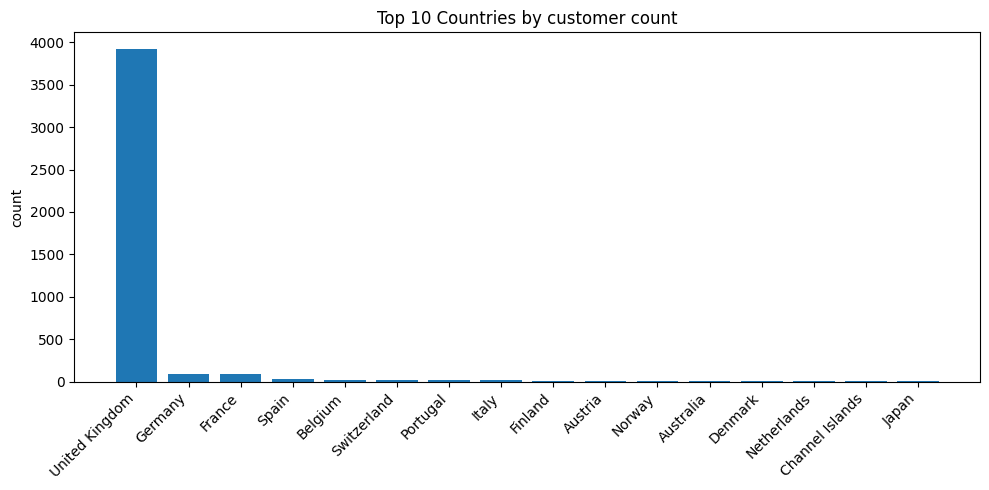

In [27]:

top16 = Number_of_customer.sort_values(ascending=False).head(16)

plt.figure(figsize=(10, 5))
plt.bar(top16.index, top16.values)
plt.xticks(rotation=45, ha='right')
plt.ylabel('count')
plt.title('Top 10 Countries by customer count')
plt.tight_layout()
plt.show()

##  5. what are the overall top StockCodes.

#### Based on Revenue and Frequency

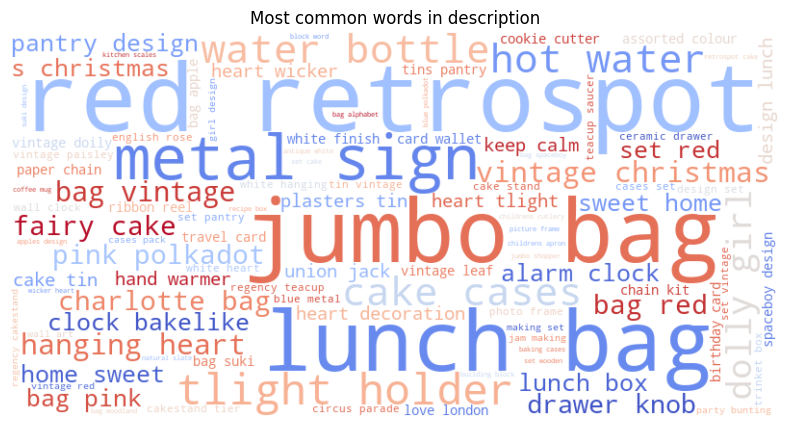

In [28]:

text = ' '.join(df['Description'].astype(str).tolist())

text = re.sub(r'[^A-Za-z\s]', '', text)

text = text.lower()

stopwords = set(STOPWORDS)
text = ' '.join(word for word in text.split() if word not in stopwords)





wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100, colormap='coolwarm').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most common words in description")
plt.show()

In [29]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,day_number,day_name,Total_sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,2,Wednesday,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2,Wednesday,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,2,Wednesday,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2,Wednesday,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2,Wednesday,20.34


### Based on Revenue 

In [30]:

best_stock = df.groupby('StockCode')['Total_sales'].sum().sort_values(ascending=False).head(20).reset_index()

# Cross-reference with Description (take most common description per StockCode)
stock_desc = df.groupby('StockCode')['Description'].agg(lambda x: x.mode()[0]).reset_index()

# Merge and show top 20
top_products = best_stock.merge(stock_desc, on='StockCode')
print("\nTOP 20 BEST-SELLING PRODUCTS:")
print(top_products[['StockCode', 'Description', 'Total_sales']])


TOP 20 BEST-SELLING PRODUCTS:
   StockCode                         Description  Total_sales
0      23843         PAPER CRAFT , LITTLE BIRDIE    168469.60
1      22423            REGENCY CAKESTAND 3 TIER    142264.75
2     85123A  WHITE HANGING HEART T-LIGHT HOLDER    100547.45
3     85099B             JUMBO BAG RED RETROSPOT     85040.54
4      23166      MEDIUM CERAMIC TOP STORAGE JAR     81416.73
5       POST                             POSTAGE     77803.96
6      47566                       PARTY BUNTING     68785.23
7      84879       ASSORTED COLOUR BIRD ORNAMENT     56413.03
8          M                              Manual     53419.93
9      23084                  RABBIT NIGHT LIGHT     51251.24
10     22502          PICNIC BASKET WICKER SMALL     47348.35
11     79321                       CHILLI LIGHTS     46265.11
12     22086     PAPER CHAIN KIT 50'S CHRISTMAS      42584.13
13     21137            BLACK RECORD COVER FRAME     39045.80
14     23203            JUMBO BAG VINTA

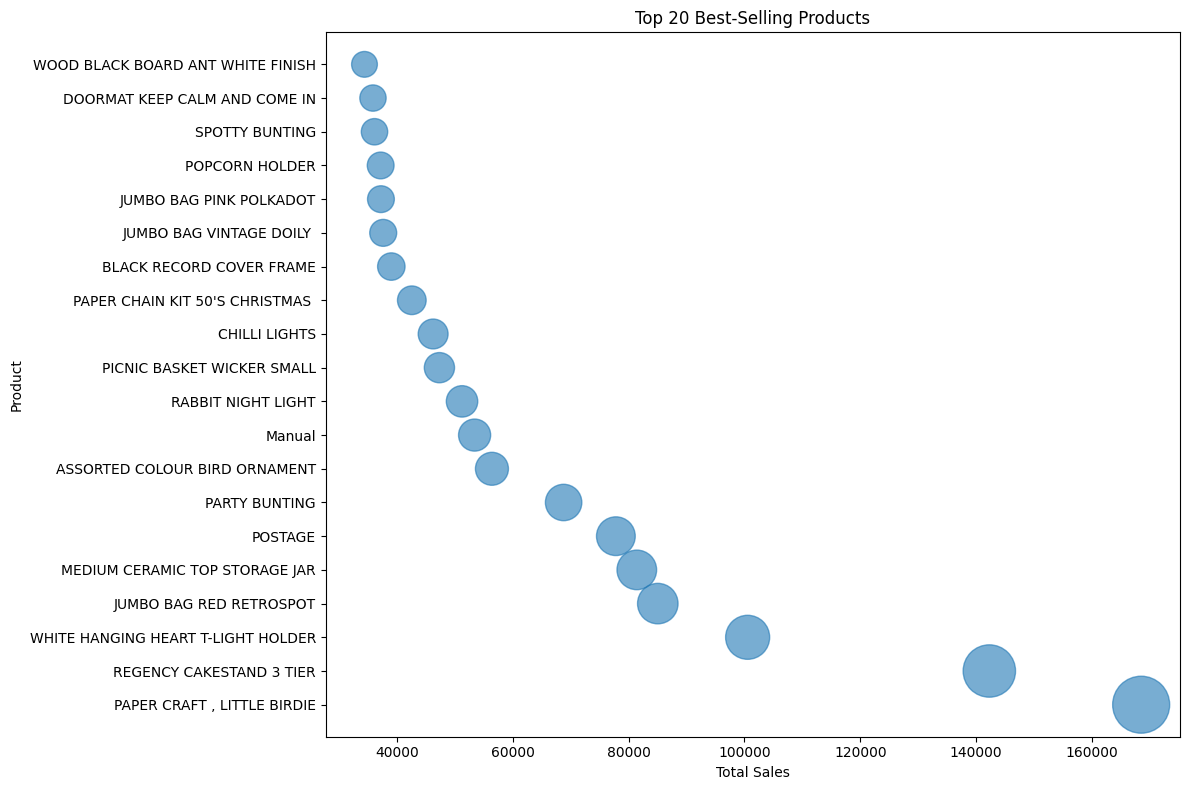

In [35]:


plt.figure(figsize=(12, 8))
plt.scatter(
    top_products['Total_sales'],
    top_products['Description'],
    s=top_products['Total_sales'] / 100,
    alpha=0.6
)

plt.xlabel('Total Sales')
plt.ylabel('Product')
plt.title('Top 20 Best-Selling Products')
plt.tight_layout()
plt.show()

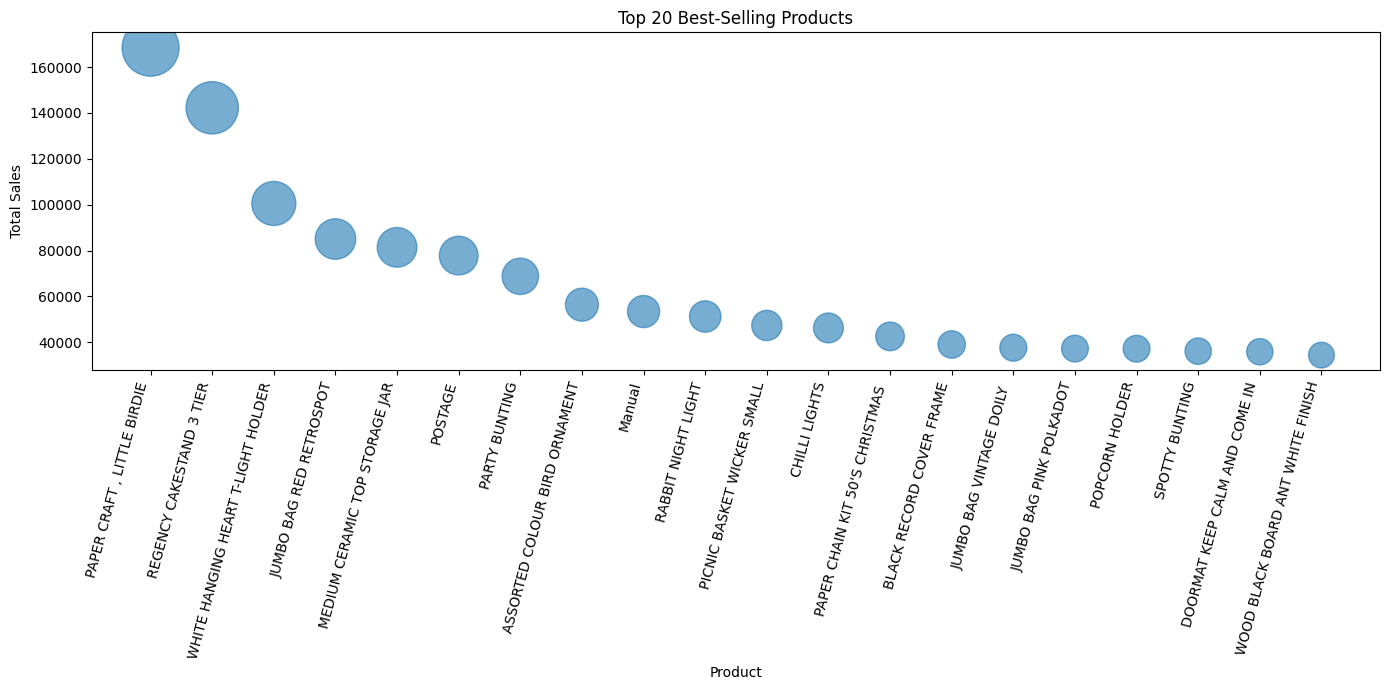

In [37]:





top_products = top_products.sort_values('Total_sales', ascending=False).reset_index(drop=True)
top_products['rank'] = top_products.index + 1

plt.figure(figsize=(14, 7))
plt.scatter(
    top_products['rank'],
    top_products['Total_sales'],
    s=top_products['Total_sales'] / 100,   
    alpha=0.6
)

plt.xticks(top_products['rank'], top_products['Description'], rotation=75, ha='right')
plt.xlabel('Product')
plt.ylabel('Total Sales')
plt.title('Top 20 Best-Selling Products')
plt.tight_layout()
plt.show()

### Based on Frequency

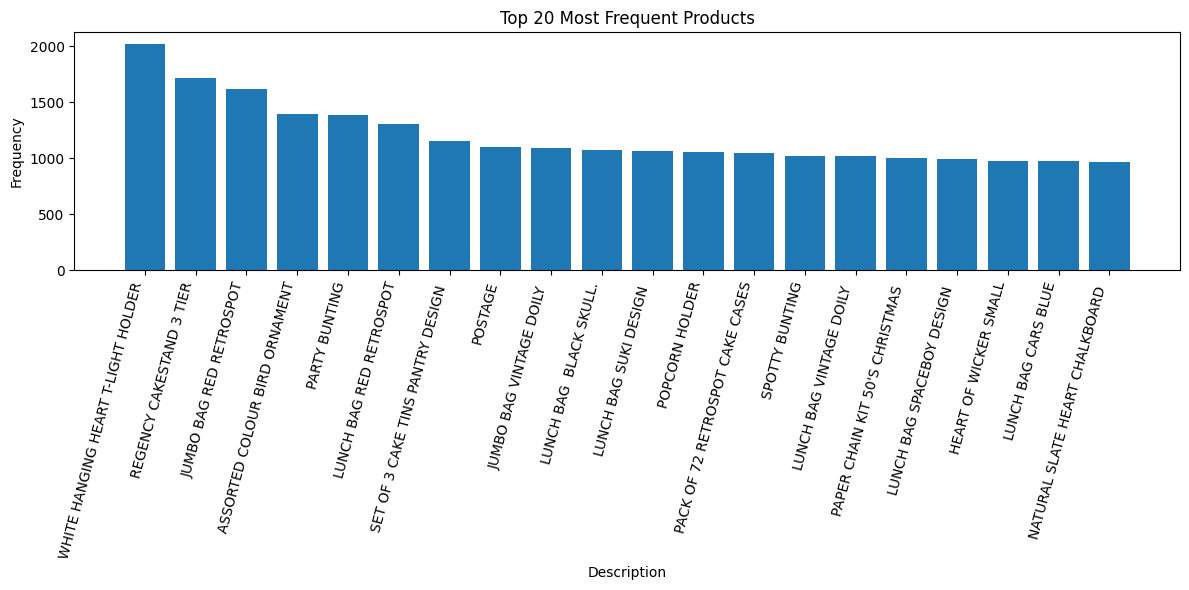

In [33]:

stock_freq = df['StockCode'].value_counts().head(20).reset_index()
stock_freq.columns = ['StockCode', 'Frequency']

stock_desc = df.groupby('StockCode')['Description'].agg(lambda x: x.mode()[0]).reset_index()

freq_table = stock_freq.merge(stock_desc, on='StockCode')

plt.figure(figsize=(12, 6))
plt.bar(freq_table['Description'], freq_table['Frequency'])
plt.xticks(rotation=75, ha='right')
plt.xlabel('Description')
plt.ylabel('Frequency')
plt.title('Top 20 Most Frequent Products')
plt.tight_layout()
plt.show()

# Regional Analysis


## First lets segment the countries based on regions

# Euroupean Analysis

In [41]:
country_to_region = {
    'United Kingdom': 'UK',

    # Europe
    'Germany': 'Europe',
    'France': 'Europe',
    'Spain': 'Europe',
    'Belgium': 'Europe',
    'Switzerland': 'Europe',
    'Portugal': 'Europe',
    'Italy': 'Europe',
    'Finland': 'Europe',
    'Austria': 'Europe',
    'Norway': 'Europe',
    'Denmark': 'Europe',
    'Netherlands': 'Europe',
    'Channel Islands': 'Europe',
    'Sweden': 'Europe',
    'Poland': 'Europe',
    'Greece': 'Europe',
    'EIRE': 'Europe',
    'Czech Republic': 'Europe',
    'European Community': 'Europe',
    'Iceland': 'Europe',
    'Lithuania': 'Europe',

    # Asia
    'Japan': 'Asia',
    'Israel': 'Asia',
    'Saudi Arabia': 'Asia',
    'Lebanon': 'Asiat',
    'Bahrain': 'Asia',
    'United Arab Emirates': 'Asia',
    'Singapore': 'Asia',
    'Cyprus': 'Asia',

    # Americas
    'USA': 'America',
    'Canada': 'America',
    'Brazil': 'America',

    # Other
    'Australia': 'Oceania',
    'RSA': 'Africa',
    'Unspecified': 'Other',

}


df['Region'] = df['Country'].map(country_to_region).fillna('Other')

In [42]:
europe_df = df[df['Region'] == 'Europe'].copy()



## 1. On what days do the European market chooses to shop on?

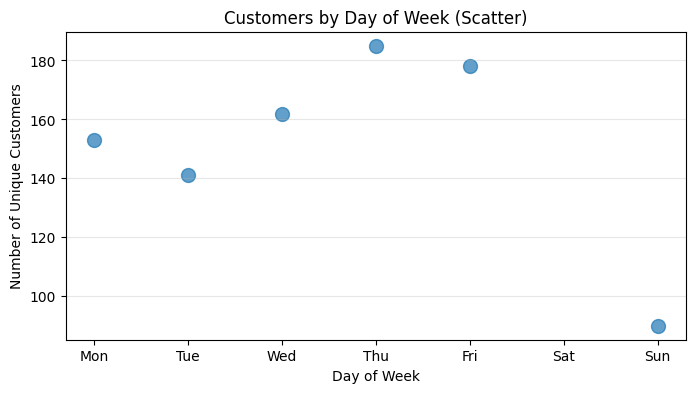

In [43]:
day_counts = europe_df.groupby('day_name')['CustomerID'].nunique().reset_index(name='unique_customers')

weekday_order = {
    'Monday': 0,
    'Tuesday': 1,
    'Wednesday': 2,
    'Thursday': 3,
    'Friday': 4,
    'Saturday': 5,
    'Sunday': 6
}

day_counts['day_num'] = day_counts['day_name'].map(weekday_order)

plt.figure(figsize=(8, 4))
plt.scatter(day_counts['day_num'], day_counts['unique_customers'], s=100, alpha=0.7)

plt.xticks(
    ticks=[0, 1, 2, 3, 4, 5, 6],
    labels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
)
plt.xlabel('Day of Week')
plt.ylabel('Number of Unique Customers')
plt.title('Customers by Day of Week (Scatter)')
plt.grid(True, axis='y', alpha=0.3)
plt.show()

#  2. how much revenue is being generated from the Euroupean region?

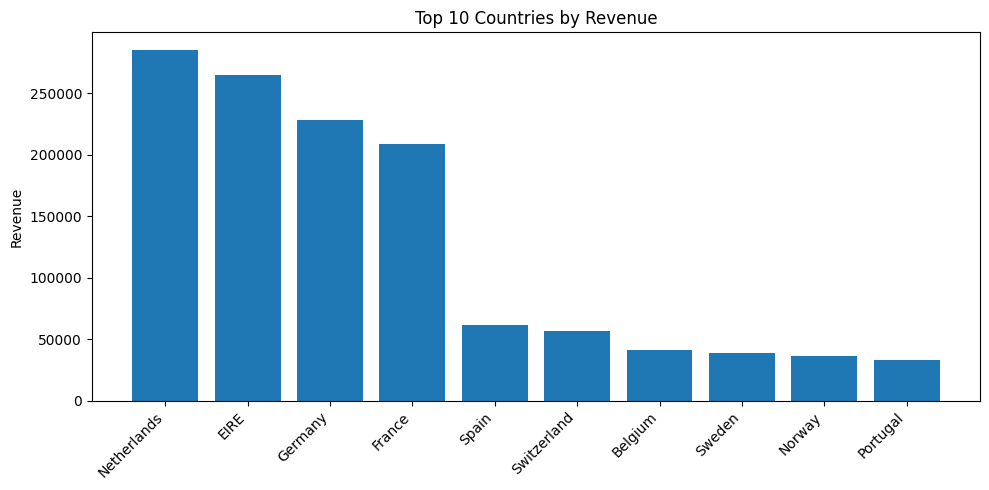

In [46]:


europe_df['Total_sales']= europe_df['Quantity'] * europe_df['UnitPrice']

revenue_by_country = europe_df.groupby('Country')['Total_sales'].sum().sort_values(ascending=False).reset_index()

revenue_by_country['Percentage (%)'] = (
    revenue_by_country['Total_sales'] / revenue_by_country['Total_sales'].sum() * 100
).round(2)

revenue_by_country



top10 = revenue_by_country.head(10)

plt.figure(figsize=(10, 5))
plt.bar(top10['Country'], top10['Total_sales'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Revenue')
plt.title('Top 10 Countries by Revenue')
plt.tight_layout()
plt.show()

# 4. how many customers belong to each region.

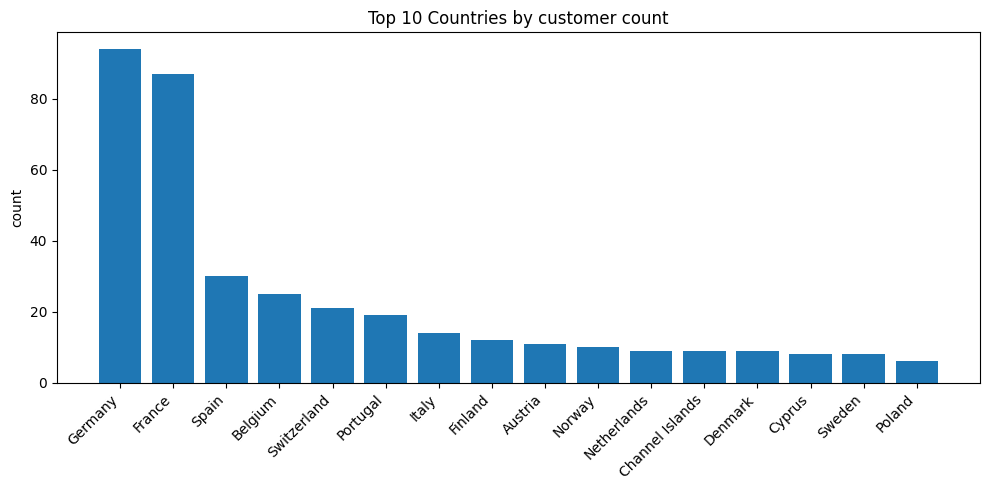

In [70]:


Number_of_customer = europe_df.groupby('Country')['CustomerID'].nunique().sort_values(ascending=False)
top16 = Number_of_customer.sort_values(ascending=False).head(16)

plt.figure(figsize=(10, 5))
plt.bar(top16.index, top16.values)
plt.xticks(rotation=45, ha='right')
plt.ylabel('count')
plt.title('Top 10 Countries by customer count')
plt.tight_layout()
plt.show()

### Observation: Thats interesting eventhough The netherlands generates more revenue , Germany has more customers!!

#  5. what are the overall top StockCodes.

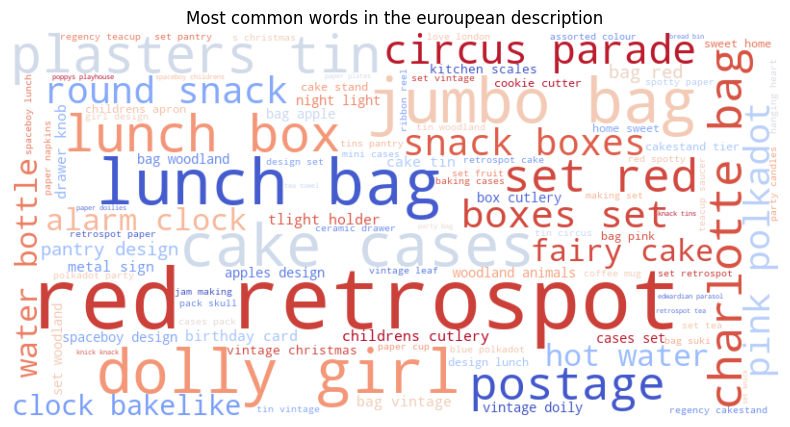


TOP 20 BEST-SELLING PRODUCTS:
   StockCode                          Description  Total_sales
0       POST                              POSTAGE     67411.50
1      22423             REGENCY CAKESTAND 3 TIER     27690.30
2          M                               Manual     21101.40
3      23084                   RABBIT NIGHT LIGHT     19305.92
4      22326  ROUND SNACK BOXES SET OF4 WOODLAND      16807.15
5      22629                  SPACEBOY LUNCH BOX      12721.05
6      22630                 DOLLY GIRL LUNCH BOX     10654.20
7     84997D      CHILDRENS CUTLERY POLKADOT PINK      9637.96
8      22328   ROUND SNACK BOXES SET OF 4 FRUITS       8325.50
9      21731        RED TOADSTOOL LED NIGHT LIGHT      8196.75
10     22554     PLASTERS IN TIN WOODLAND ANIMALS      7869.90
11    85099B              JUMBO BAG RED RETROSPOT      7346.13
12    84997C      CHILDRENS CUTLERY POLKADOT BLUE      7286.86
13     22551             PLASTERS IN TIN SPACEBOY      7166.55
14     23245           S

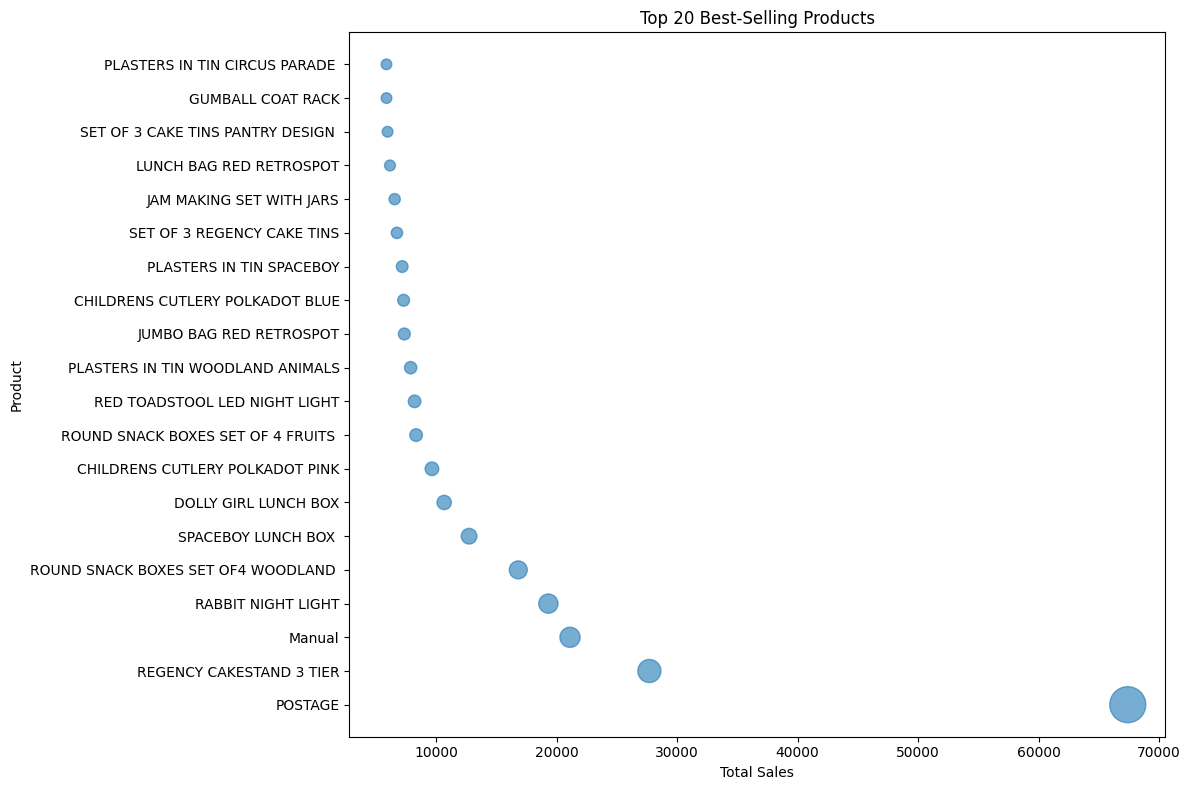

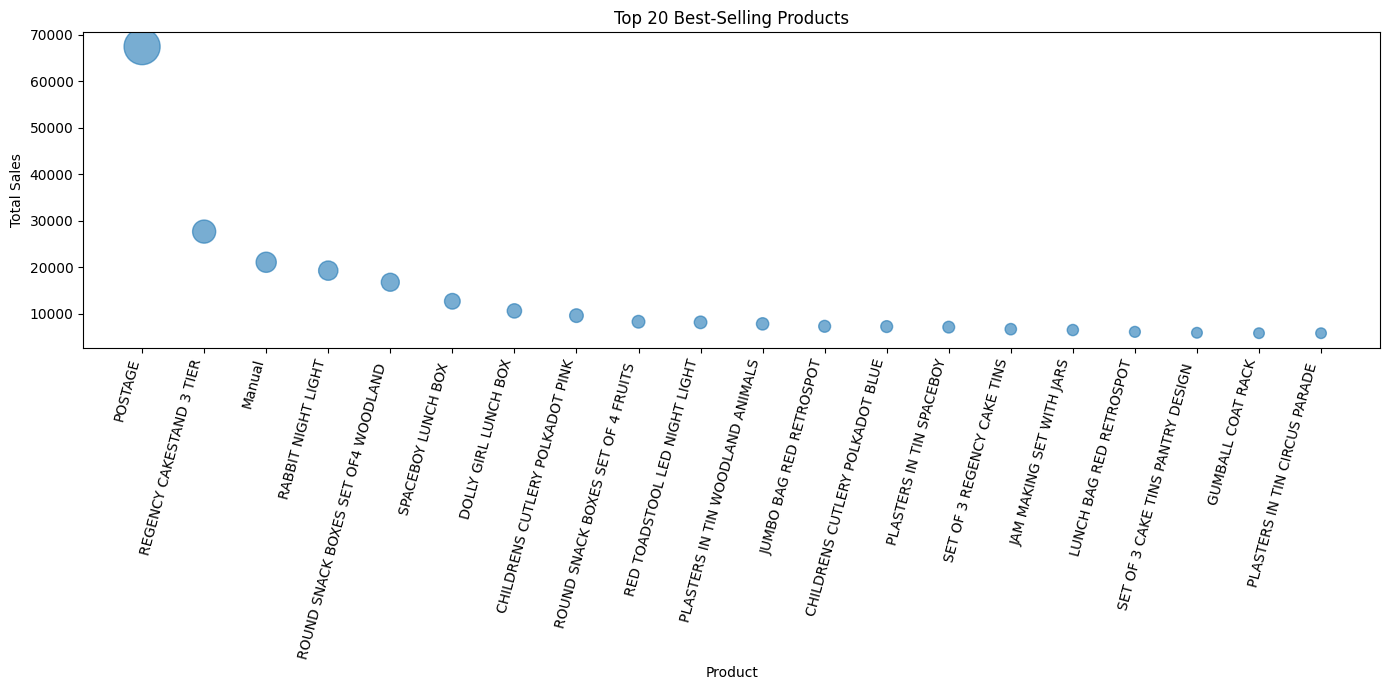

In [46]:

text = ' '.join(europe_df['Description'].astype(str).tolist())

text = re.sub(r'[^A-Za-z\s]', '', text)

text = text.lower()

stopwords = set(STOPWORDS)
text = ' '.join(word for word in text.split() if word not in stopwords)





wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100, colormap='coolwarm').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most common words in the euroupean description")
plt.show()


best_stock = europe_df.groupby('StockCode')['Total_sales'].sum().sort_values(ascending=False).head(20).reset_index()

# Cross-reference with Description (take most common description per StockCode)
stock_desc = europe_df.groupby('StockCode')['Description'].agg(lambda x: x.mode()[0]).reset_index()

# Merge and show top 20
top_products = best_stock.merge(stock_desc, on='StockCode')
print("\nTOP 20 BEST-SELLING PRODUCTS:")
print(top_products[['StockCode', 'Description', 'Total_sales']])

plt.figure(figsize=(12, 8))
plt.scatter(
    top_products['Total_sales'],
    top_products['Description'],
    s=top_products['Total_sales'] / 100,
    alpha=0.6
)

plt.xlabel('Total Sales')
plt.ylabel('Product')
plt.title('Top 20 Best-Selling Products')
plt.tight_layout()
plt.show()




top_products = top_products.sort_values('Total_sales', ascending=False).reset_index(drop=True)
top_products['rank'] = top_products.index + 1

plt.figure(figsize=(14, 7))
plt.scatter(
    top_products['rank'],
    top_products['Total_sales'],
    s=top_products['Total_sales'] / 100,   # adjust this if bubbles are too big/small
    alpha=0.6
)

plt.xticks(top_products['rank'], top_products['Description'], rotation=75, ha='right')
plt.xlabel('Product')
plt.ylabel('Total Sales')
plt.title('Top 20 Best-Selling Products')
plt.tight_layout()
plt.show()

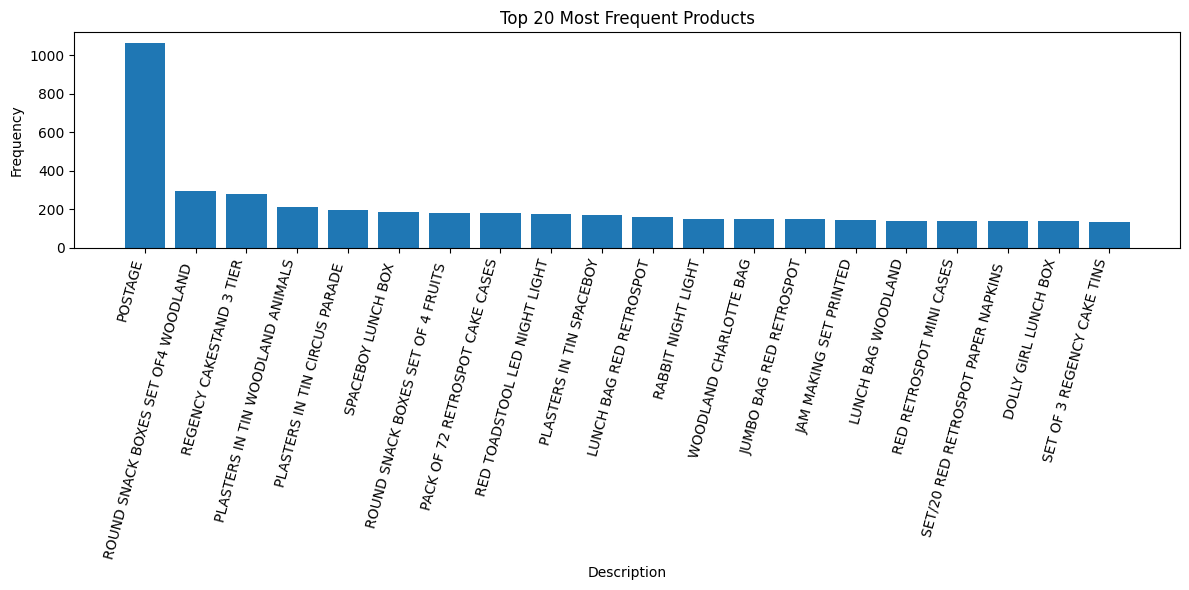

In [51]:

stock_freq = europe_df['StockCode'].value_counts().head(20).reset_index()
stock_freq.columns = ['StockCode', 'Frequency']

stock_desc = europe_df.groupby('StockCode')['Description'].agg(lambda x: x.mode()[0]).reset_index()

freq_table = stock_freq.merge(stock_desc, on='StockCode')

plt.figure(figsize=(12, 6))
plt.bar(freq_table['Description'], freq_table['Frequency'])
plt.xticks(rotation=75, ha='right')
plt.xlabel('Description')
plt.ylabel('Frequency')
plt.title('Top 20 Most Frequent Products')
plt.tight_layout()
plt.show()

# Asian Analysis

In [65]:
asia_df = df[df['Region'] == 'Asia'].copy()
asia_df['Total_sales'] = asia_df['Quantity'] * asia_df['UnitPrice']
asia_df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,day_number,day_name,Total_sales,Region
9783,537218,85016,SET OF 6 VINTAGE NOTELETS KIT,6,2010-12-05 15:46:00,2.55,12763,Japan,6,Sunday,15.30,Asia
9784,537218,21506,"FANCY FONT BIRTHDAY CARD,",12,2010-12-05 15:46:00,0.42,12763,Japan,6,Sunday,5.04,Asia
9785,537218,22716,CARD CIRCUS PARADE,12,2010-12-05 15:46:00,0.42,12763,Japan,6,Sunday,5.04,Asia
9786,537218,22983,CARD BILLBOARD FONT,12,2010-12-05 15:46:00,0.42,12763,Japan,6,Sunday,5.04,Asia
9787,537218,22030,SWALLOWS GREETING CARD,12,2010-12-05 15:46:00,0.42,12763,Japan,6,Sunday,5.04,Asia
...,...,...,...,...,...,...,...,...,...,...,...,...
479966,577228,21528,DAIRY MAID TRADITIONAL TEAPOT,1,2011-11-18 12:07:00,6.95,12391,Cyprus,4,Friday,6.95,Asia
479967,577228,22308,TEA COSY BLUE STRIPE,1,2011-11-18 12:07:00,2.55,12391,Cyprus,4,Friday,2.55,Asia
479968,577228,51014A,"FEATHER PEN,HOT PINK",12,2011-11-18 12:07:00,0.39,12391,Cyprus,4,Friday,4.68,Asia
479969,577228,21034,REX CASH+CARRY JUMBO SHOPPER,1,2011-11-18 12:07:00,0.95,12391,Cyprus,4,Friday,0.95,Asia


In [66]:
asia_df['Country'].nunique()

7

# which days do the Customers in Asia choose to shop on?

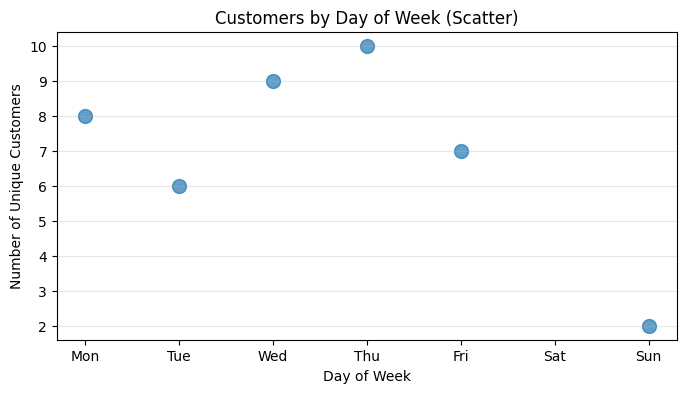

In [67]:
day_counts = asia_df.groupby('day_name')['CustomerID'].nunique().reset_index(name='unique_customers')

weekday_order = {
    'Monday': 0,
    'Tuesday': 1,
    'Wednesday': 2,
    'Thursday': 3,
    'Friday': 4,
    'Saturday': 5,
    'Sunday': 6
}

day_counts['day_num'] = day_counts['day_name'].map(weekday_order)

plt.figure(figsize=(8, 4))
plt.scatter(day_counts['day_num'], day_counts['unique_customers'], s=100, alpha=0.7)

plt.xticks(
    ticks=[0, 1, 2, 3, 4, 5, 6],
    labels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
)
plt.xlabel('Day of Week')
plt.ylabel('Number of Unique Customers')
plt.title('Customers by Day of Week (Scatter)')
plt.grid(True, axis='y', alpha=0.3)
plt.show()

#  2. how much revenue is being generated from the Asian region?

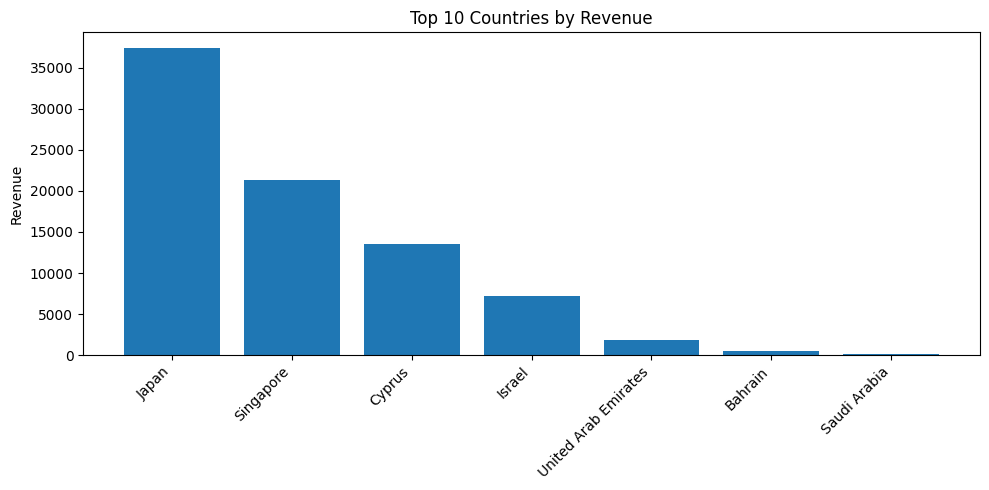

In [69]:


asia_df['Total_sales']= asia_df['Quantity'] * asia_df['UnitPrice']

revenue_by_country = asia_df.groupby('Country')['Total_sales'].sum().sort_values(ascending=False).reset_index()

revenue_by_country['Percentage (%)'] = (
    revenue_by_country['Total_sales'] / revenue_by_country['Total_sales'].sum() * 100
).round(2)

revenue_by_country



top10 = revenue_by_country.head(10)

plt.figure(figsize=(10, 5))
plt.bar(top10['Country'], top10['Total_sales'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Revenue')
plt.title('Top 10 Countries by Revenue')
plt.tight_layout()
plt.show()

# 4. how many customers belong to the Asian region.

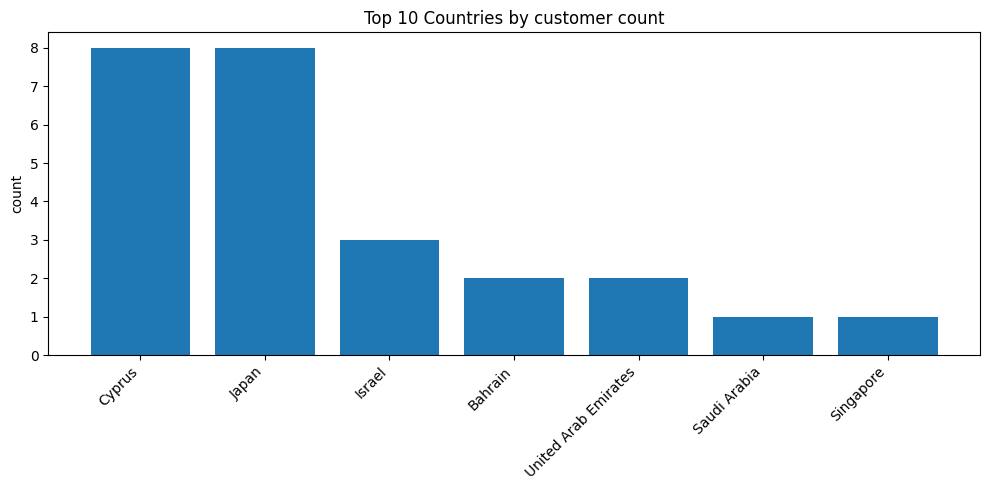

In [74]:


Number_of_customer = asia_df.groupby('Country')['CustomerID'].nunique().sort_values(ascending=False)
top16 = Number_of_customer.sort_values(ascending=False).head(16)

plt.figure(figsize=(10, 5))
plt.bar(top16.index, top16.values)
plt.xticks(rotation=45, ha='right')
plt.ylabel('count')
plt.title('Top 10 Countries by customer count')
plt.tight_layout()
plt.show()

#  5. what are the overall Asian top StockCodes.

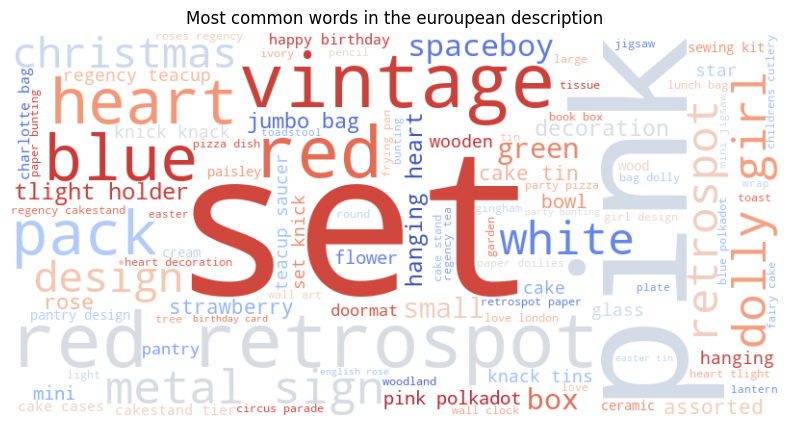


TOP 20 BEST-SELLING PRODUCTS:
   StockCode                         Description  Total_sales
0          M                              Manual     12479.59
1      23084                  RABBIT NIGHT LIGHT      6100.32
2      22328  ROUND SNACK BOXES SET OF 4 FRUITS       3847.50
3      22423            REGENCY CAKESTAND 3 TIER      1287.30
4      21218              RED SPOTTY BISCUIT TIN       858.00
5      20750            RED RETROSPOT MINI CASES       793.80
6      47566                       PARTY BUNTING       752.90
7      21217       RED RETROSPOT ROUND CAKE TINS       751.80
8      23240    SET OF 4 KNICK KNACK TINS DOILY        643.75
9      21216    SET 3 RETROSPOT TEA,COFFEE,SUGAR       612.00
10     23238   SET OF 4 KNICK KNACK TINS LONDON        589.80
11     22827  RUSTIC  SEVENTEEN DRAWER SIDEBOARD       580.00
12     22662         LUNCH BAG DOLLY GIRL DESIGN       534.00
13    85123A  WHITE HANGING HEART T-LIGHT HOLDER       524.05
14     22561         WOODEN SCHOOL COLO

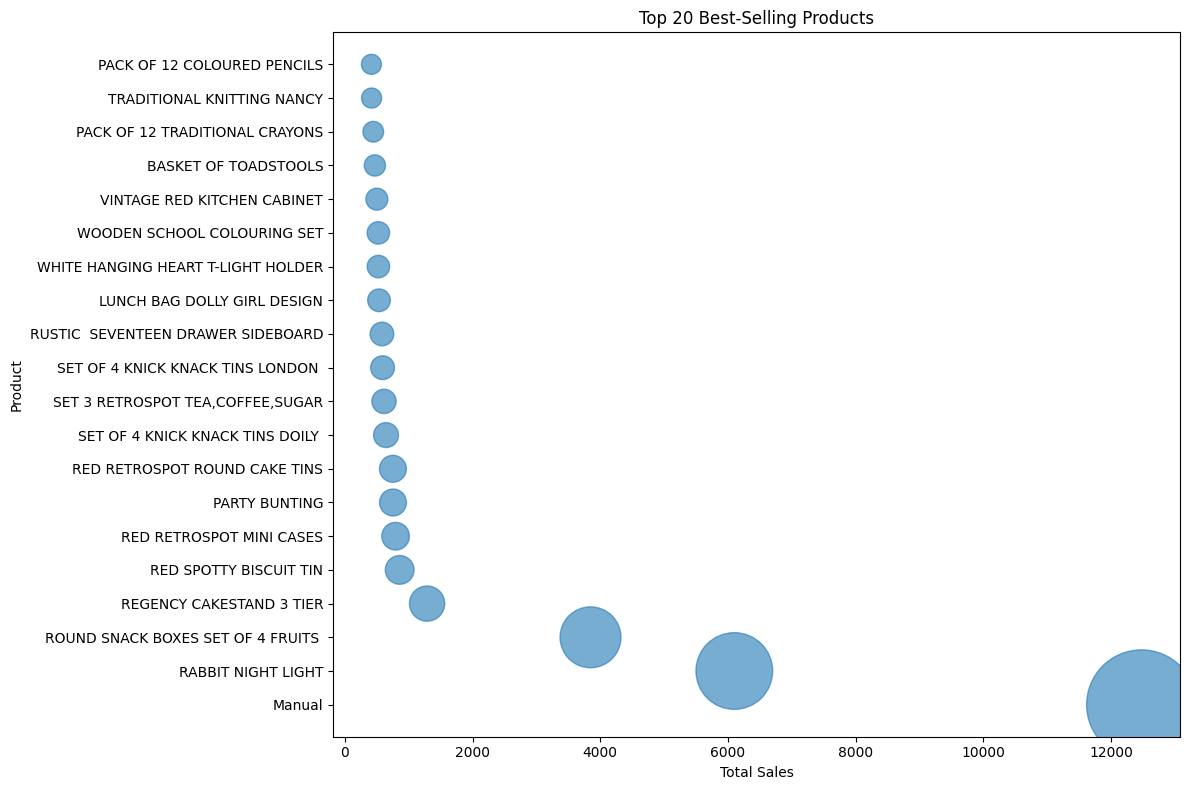

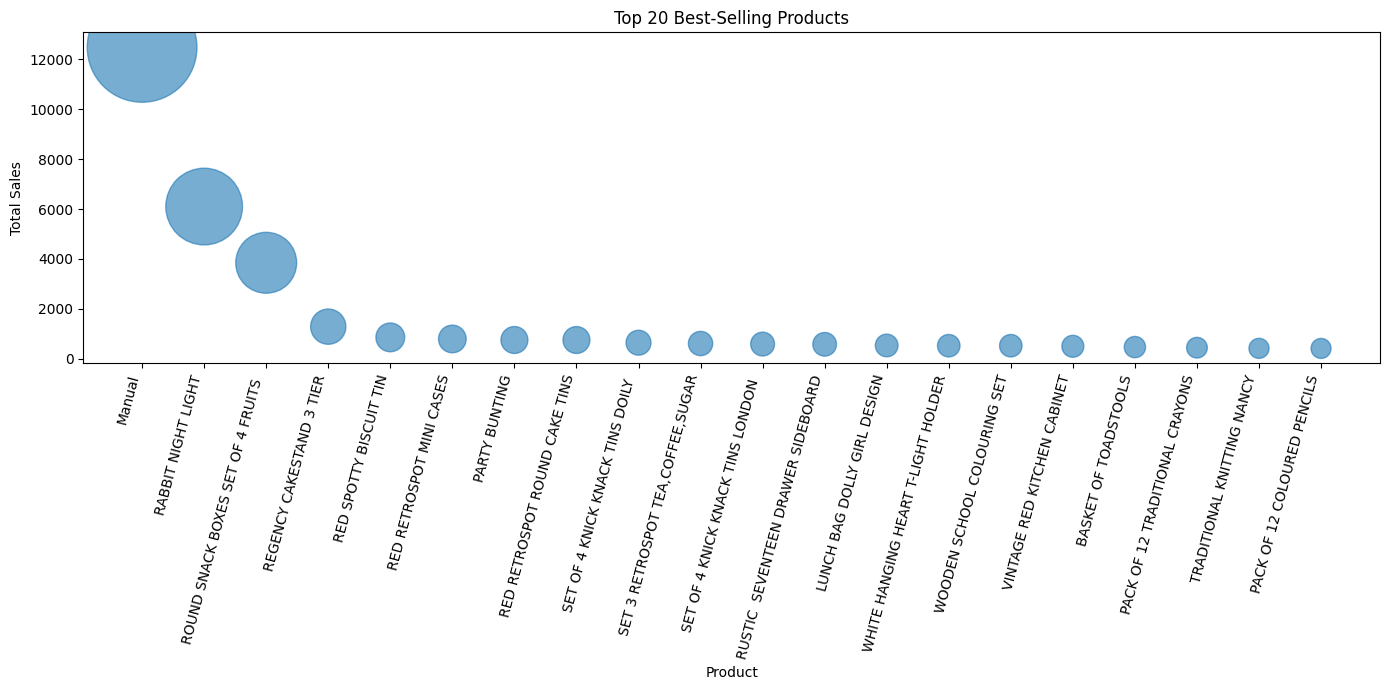

In [78]:

text = ' '.join(asia_df['Description'].astype(str).tolist())

text = re.sub(r'[^A-Za-z\s]', '', text)

text = text.lower()

stopwords = set(STOPWORDS)
text = ' '.join(word for word in text.split() if word not in stopwords)





wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100, colormap='coolwarm').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most common words in the euroupean description")
plt.show()


best_stock = asia_df.groupby('StockCode')['Total_sales'].sum().sort_values(ascending=False).head(20).reset_index()

# Cross-reference with Description (take most common description per StockCode)
stock_desc = asia_df.groupby('StockCode')['Description'].agg(lambda x: x.mode()[0]).reset_index()

# Merge and show top 20
top_products = best_stock.merge(stock_desc, on='StockCode')
print("\nTOP 20 BEST-SELLING PRODUCTS:")
print(top_products[['StockCode', 'Description', 'Total_sales']])

plt.figure(figsize=(12, 8))
plt.scatter(
    top_products['Total_sales'],
    top_products['Description'],
    s=top_products['Total_sales'] / 2,
    alpha=0.6
)

plt.xlabel('Total Sales')
plt.ylabel('Product')
plt.title('Top 20 Best-Selling Products')
plt.tight_layout()
plt.show()




top_products = top_products.sort_values('Total_sales', ascending=False).reset_index(drop=True)
top_products['rank'] = top_products.index + 1

plt.figure(figsize=(14, 7))
plt.scatter(
    top_products['rank'],
    top_products['Total_sales'],
    s=top_products['Total_sales'] / 2,   # adjust this if bubbles are too big/small
    alpha=0.6
)

plt.xticks(top_products['rank'], top_products['Description'], rotation=75, ha='right')
plt.xlabel('Product')
plt.ylabel('Total Sales')
plt.title('Top 20 Best-Selling Products')
plt.tight_layout()
plt.show()

# conclusion

### After cleaning the dataset, the analysis shows that the business is overwhelmingly concentrated in the United Kingdom, which accounts for about 90.20% of customers, meaning any “global” result is heavily shaped by UK behavior rather than by truly balanced international demand.

### To solve that bias, the study separates global and regional views, which reveals that customer behavior, revenue contribution, and top-selling products differ meaningfully outside the UK. In Europe, Germany leads in customer count while the Netherlands can generate stronger revenue despite having fewer customers, showing that customer volume and revenue are not always the same thing.

### Product demand is also not uniform across regions: items such as REGENCY CAKESTAND 3 TIER, RABBIT NIGHT LIGHT, and ROUND SNACK BOX products appear repeatedly among top performers, while regional product rankings shift depending on market preferences and order value.

### Overall, this analysis suggests that the company should avoid treating international markets as one block; instead, it should use region-specific inventory, promotion, and customer targeting strategies, because the UK drives scale while non-UK regions reveal distinct revenue and product opportunities.